In [62]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [63]:
def load_data() -> dict[str, pd.DataFrame]:
    BASE = Path("..")
    data_dir = BASE / "data"
    if not data_dir.is_dir():
        raise FileNotFoundError(f"Data directory not found: {data_dir}")

    try:
        all_files = [
            f for f in data_dir.iterdir()
            if f.is_file() and str(f).__contains__(".csv")
        ]
    except OSError as exc:
        raise OSError(f"Could not list CSV files in {data_dir}") from exc

    for name in ("companies.csv", "combined_data.csv"):
        if not (data_dir / name).is_file():
            raise FileNotFoundError(f"Required CSV missing: {data_dir / name}")

    data_dict = {}
    for file in all_files:
        try:
            data_dict[file.name[:-4]] = pd.read_csv(file)
        except (OSError, pd.errors.ParserError) as exc:
            raise RuntimeError(f"Could not read CSV file: {file}") from exc

    return data_dict

## Data loading

I pull balance sheets, income statements, and cashflow statements because each shows a different part of a company's finances. Here I load the merged company-year data and the industry labels.

In [64]:
data = load_data()

## Missing-value filter

Before saving the CSVs, `filter_missing_dict()` keeps columns whose missing-to-observed count ratio is below 0.15. That keeps very sparse accounts out of the baseline.

## Merge and filing alignment

I want to compare full-year statements in the same currency. A balance sheet can be labeled Q4 while the other statements are FY, so the merge uses `SimFinId` and `Fiscal Year` instead of `Fiscal Period`. Currency is left out of the join keys. I also attach each company's industry ID.

In [65]:
companies_data = data["companies"][["SimFinId", "IndustryId"]]

combined_data = pd.merge(
    data["combined_data"],
    companies_data,
    on="SimFinId",
    how="inner",
)
combined_data = combined_data.set_index(["SimFinId"])

## Missing-value imputation

I fill gaps with each company's mean first, since companies can operate at very different scales. If that does not fill everything, I use the industry median, then the global median for anything still missing.

In [66]:
combined_data = combined_data.groupby("SimFinId").transform(
    lambda x: x.fillna(x.mean())
)
# 
combined_data = combined_data.groupby("IndustryId").transform(
    lambda x: x.fillna(x.median())
)
# 
combined_data = combined_data.fillna(combined_data.median())
combined_data = combined_data.sort_values([combined_data.index.name, "Fiscal Year"])

In [67]:
print(combined_data.columns)
print(combined_data.isna().sum())



Index(['Fiscal Year', 'Cash, Cash Equivalents & Short Term Investments',
       'Total Current Assets', 'Property, Plant & Equipment, Net',
       'Other Long Term Assets', 'Total Noncurrent Assets', 'Total Assets',
       'Payables & Accruals', 'Total Current Liabilities',
       'Total Noncurrent Liabilities', 'Total Liabilities',
       'Share Capital & Additional Paid-In Capital', 'Retained Earnings',
       'Total Equity', 'Total Liabilities & Equity', 'Revenue',
       'Operating Expenses', 'Selling, General & Administrative',
       'Operating Income (Loss)', 'Non-Operating Income (Loss)',
       'Interest Expense, Net', 'Pretax Income (Loss), Adj.',
       'Pretax Income (Loss)', 'Income (Loss) from Continuing Operations',
       'Net Income', 'Net Income (Common)', 'Net Income/Starting Line',
       'Depreciation & Amortization', 'Non-Cash Items',
       'Change in Working Capital', 'Net Cash from Operating Activities',
       'Change in Fixed Assets & Intangibles',
       'Ne

## Prediction target

`shift(-1)` places each company's next reported Total Liabilities beside its current value. The target is 1 when liabilities increase the following year.

In [68]:

liabilities = combined_data.groupby("SimFinId")["Total Liabilities"].shift(-1)

combined_data["target"] = np.where(
    liabilities.isna(),
    np.nan,
    (liabilities > combined_data["Total Liabilities"])
)

combined_data = combined_data.dropna(subset=["target"])
combined_data["target"] = combined_data["target"].astype(int) 

## Time-based train/test split

I train on years before 2024 and test on later years. This keeps later filings out of training. The current labeled test set has 2024 rows; there are no labeled 2025 rows because there is no following year in these data.

In [69]:
train = combined_data[combined_data["Fiscal Year"] < 2024]
test = combined_data[combined_data["Fiscal Year"] >= 2024]
if train.empty or test.empty:
    raise ValueError("Time-based split produced an empty train or test set")

In [70]:
train_features = train.drop(columns=["target"])
train_label = train["target"]
test_features = test.drop(columns=["target"])
test_label = test["target"]

## Logistic regression baseline

I start with logistic regression to get a simple baseline from one-year snapshots. `class_weight="balanced"` gives more influence to whichever outcome is less common in the training labels.

In [71]:
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(train_features, train_label)

/home/karan/Projects/FinFormer/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [72]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

y_hat = model.predict(train_features)

conf_matrix = confusion_matrix(y_pred=y_hat, y_true=train_label)

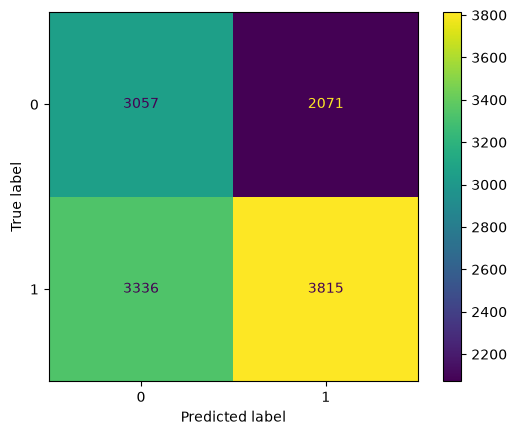

In [73]:
ConfusionMatrixDisplay(conf_matrix).plot()

## Classification reports

I compare precision, recall, and F1 for both classes on the training and test years. The test report helps me see how well this baseline carries over to later filings.

In [74]:
pd.DataFrame(
    classification_report(train_label, y_hat, output_dict=True)
).T

,precision,recall,f1-score,support
0,0.478179,0.596139,0.530683,5128.000000
1,0.648148,0.533492,0.585257,7151.000000
accuracy,0.559655,0.559655,0.559655,0.559655
macro avg,0.563164,0.564815,0.557970,12279.000000
weighted avg,0.577165,0.559655,0.562466,12279.000000


In [75]:
pd.DataFrame(
    classification_report(
        test_label, model.predict(test_features), output_dict=True
    )
).T

,precision,recall,f1-score,support
0,0.43617,0.672131,0.529032,61.00000
1,0.69697,0.464646,0.557576,99.00000
accuracy,0.54375,0.543750,0.543750,0.54375
macro avg,0.56657,0.568389,0.543304,160.00000
weighted avg,0.59754,0.543750,0.546694,160.00000
